# 0.5% Vendor Sample Distribution Validation

## Objective

Check whether the persisted 0.5% vendor-matchid sample reproduces the distributions in the full retained production population for `2026-09-16`.

The comparison covers the three matchid-level measures used by the vendor activity analysis:

- `total_cookie_count`: distinct eligible vendor cookies in each vendor-matchid
- `overlapping_cookie_count`: distinct eligible vendor cookies also observed in same-day logevents
- `activity_coverage_pct`: `100 × overlapping_cookie_count / total_cookie_count`

## Scope

- Vendors: Experian, LiveRamp, and Throtle
- Production baseline: all rows in the persisted eligibility tables
- Sample cohort: distinct matchids in the persisted 0.5% membership tables
- Comparison unit: vendor-matchid
- Source day: `2026-09-16`

This notebook uses the persisted tables directly. It does not recompute eligibility filters, tune line thresholds, or create another sample. The result therefore tests representativeness within the retained production population, not the upstream eligibility rules.

In [1]:
from __future__ import annotations

import importlib
import sys
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import LogNorm

SOURCE_DAY = date.fromisoformat('2026-09-16')
SAMPLE_RATE_PCT = 0.5
FORCE_REFRESH = False

# Pragmatic diagnostics, not formal hypothesis-test thresholds.
MAX_SAMPLE_RATE_ERROR_PCT_POINTS = 0.02
MAX_MEAN_ERROR_PCT = 1.0
MAX_ECDF_GAP = 0.005

OUTPUT_DIR = Path('outputs') / 'vendor_activity_coverage'
FIGURE_DIR = OUTPUT_DIR / 'figures'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

CACHE_KEY = f'{SOURCE_DAY}_0p5pct'
COMPARISON_CACHE = (
    OUTPUT_DIR / f'sample_distribution_comparison_{CACHE_KEY}.csv'
)

PRODUCTION_TABLES = {
    'experian': 'iceberg.jteixeira_ipa.nscreen_eligible_matchids_experian_20260916_line_filter_v1',
    'liveramp': 'iceberg.jteixeira_ipa.nscreen_eligible_matchids_liveramp_20260916_line_filter_v1',
    'throtle': 'iceberg.jteixeira_ipa.nscreen_eligible_matchids_throtle_20260916_line_filter_v1',
}
SAMPLE_TABLES = {
    'experian': 'iceberg.jteixeira_ipa.nscreen_membership_sample_experian_20260916_line_filter_v1_0p5pct',
    'liveramp': 'iceberg.jteixeira_ipa.nscreen_membership_sample_liveramp_20260916_line_filter_v1_0p5pct',
    'throtle': 'iceberg.jteixeira_ipa.nscreen_membership_sample_throtle_20260916_line_filter_v1_0p5pct',
}
VENDOR_LABELS = {
    'experian': 'Experian',
    'liveramp': 'LiveRamp',
    'throtle': 'Throtle',
}
VENDOR_COLORS = {
    'experian': '#4C78A8',
    'liveramp': '#F58518',
    'throtle': '#54A24B',
}

plt.style.use('seaborn-v0_8-whitegrid')
pd.options.display.float_format = '{:,.4f}'.format

print(f'Cache: {COMPARISON_CACHE}')
print(f'Nominal sample rate: {SAMPLE_RATE_PCT:g}%')

Cache: outputs/vendor_activity_coverage/sample_distribution_comparison_2026-09-16_0p5pct.csv
Nominal sample rate: 0.5%


## Load grouped production and sample counts

Each sample membership table contains complete membership stars, so it has multiple rows per matchid. The query first reduces each sample table to distinct matchids. It then joins those matchids to the corresponding full eligibility table, which supplies the production metric values.

The warehouse returns one row per vendor and count combination. `production_matchid_count` and `sample_matchid_count` are frequency weights, keeping the local result compact without approximating either cohort.

In [2]:
production_parts = [
    f"""
    SELECT
        '{vendor}' AS vendor,
        matchid,
        total_cookie_count,
        overlapping_cookie_count
    FROM {table_name}
    WHERE day = DATE '{SOURCE_DAY}'
    """
    for vendor, table_name in PRODUCTION_TABLES.items()
]
sample_parts = [
    f"""
    SELECT '{vendor}' AS vendor, matchid
    FROM {table_name}
    WHERE day = DATE '{SOURCE_DAY}'
    GROUP BY matchid
    """
    for vendor, table_name in SAMPLE_TABLES.items()
]

COMPARISON_QUERY = f"""
WITH production AS (
    {' UNION ALL '.join(production_parts)}
),
sample_matchids AS (
    {' UNION ALL '.join(sample_parts)}
)
SELECT
    production.vendor,
    production.total_cookie_count,
    production.overlapping_cookie_count,
    count(*) AS production_matchid_count,
    count(sample_matchids.matchid) AS sample_matchid_count
FROM production
LEFT JOIN sample_matchids
    ON production.vendor = sample_matchids.vendor
   AND production.matchid = sample_matchids.matchid
GROUP BY
    production.vendor,
    production.total_cookie_count,
    production.overlapping_cookie_count
ORDER BY
    production.vendor,
    production.total_cookie_count,
    production.overlapping_cookie_count
"""

def run_query(sql: str) -> pd.DataFrame:
    config_dir = Path.home() / '.pulsepoint'
    if str(config_dir) not in sys.path:
        sys.path.insert(0, str(config_dir))

    from dotenv import load_dotenv

    load_dotenv(config_dir / '.env', override=False)
    dbfuncs = importlib.import_module('dbfuncs')
    return dbfuncs.query2df(sql, print_time=True)

if COMPARISON_CACHE.exists() and not FORCE_REFRESH:
    stats = pd.read_csv(COMPARISON_CACHE)
    print(f'Loaded cache: {COMPARISON_CACHE}')
else:
    stats = run_query(COMPARISON_QUERY)
    stats.to_csv(COMPARISON_CACHE, index=False)
    print(f'Saved cache: {COMPARISON_CACHE}')

required_columns = {
    'vendor',
    'total_cookie_count',
    'overlapping_cookie_count',
    'production_matchid_count',
    'sample_matchid_count',
}
missing_columns = required_columns.difference(stats.columns)
if missing_columns:
    raise ValueError(f'Cache misses required columns: {sorted(missing_columns)}')

numeric_columns = sorted(required_columns.difference({'vendor'}))
stats[numeric_columns] = stats[numeric_columns].apply(
    pd.to_numeric,
    errors='raise',
)
stats['activity_coverage_pct'] = (
    100 * stats.overlapping_cookie_count / stats.total_cookie_count
)

assert set(stats.vendor) == set(PRODUCTION_TABLES)
assert stats.total_cookie_count.gt(0).all()
assert stats.overlapping_cookie_count.ge(1).all()
assert stats.overlapping_cookie_count.le(stats.total_cookie_count).all()
assert stats.production_matchid_count.ge(stats.sample_matchid_count).all()
assert stats.activity_coverage_pct.between(0, 100).all()

print(f'Aggregate points: {len(stats):,}')

Loaded cache: outputs/vendor_activity_coverage/sample_distribution_comparison_2026-09-16_0p5pct.csv
Aggregate points: 1,466


## Cohort size and vendor mix

Observed sample rates should remain close to 0.5% for every vendor. Production and sample vendor shares provide a separate check that independent per-vendor sampling did not distort the overall vendor mix.

In [3]:
cohort_summary = (
    stats.groupby('vendor', as_index=False)[
        ['production_matchid_count', 'sample_matchid_count']
    ]
    .sum()
    .assign(
        vendor=lambda frame: frame.vendor.map(VENDOR_LABELS),
        observed_sample_rate_pct=lambda frame: (
            100 * frame.sample_matchid_count / frame.production_matchid_count
        ),
        sample_rate_error_pct_points=lambda frame: (
            100 * frame.sample_matchid_count / frame.production_matchid_count
            - SAMPLE_RATE_PCT
        ),
        expected_sample_matchids=lambda frame: (
            frame.production_matchid_count * SAMPLE_RATE_PCT / 100
        ),
    )
)
cohort_summary['production_vendor_share_pct'] = (
    100
    * cohort_summary.production_matchid_count
    / cohort_summary.production_matchid_count.sum()
)
cohort_summary['sample_vendor_share_pct'] = (
    100
    * cohort_summary.sample_matchid_count
    / cohort_summary.sample_matchid_count.sum()
)
cohort_summary['vendor_share_delta_pct_points'] = (
    cohort_summary.sample_vendor_share_pct
    - cohort_summary.production_vendor_share_pct
)

display(cohort_summary.round(4))

,vendor,production_matchid_count,sample_matchid_count,observed_sample_rate_pct,sample_rate_error_pct_points,expected_sample_matchids,production_vendor_share_pct,sample_vendor_share_pct,vendor_share_delta_pct_points
0,Experian,44296828,221116,0.4992,-0.0008,"221,484.1400",28.1995,28.1424,-0.0571
1,LiveRamp,81711763,409049,0.5006,0.0006,"408,558.8150",52.0180,52.0615,0.0434
2,Throtle,31074933,155539,0.5005,0.0005,"155,374.6650",19.7824,19.7961,0.0137


## Distribution comparison

All statistics are weighted by matchid frequency. Quantiles therefore describe matchids, not the 1,466 aggregate rows.

Two complementary distance measures are reported:

- `total_variation`: half the absolute probability-mass difference across exact metric values
- `max_ecdf_gap`: largest absolute gap between weighted empirical cumulative distributions

The configured pass check requires an absolute weighted-mean error no larger than 1% and an ECDF gap no larger than 0.005 for every vendor-metric pair. These are pragmatic diagnostics, not formal hypothesis tests.

In [4]:
METRICS = {
    'total_cookie_count': 'Total cookies',
    'overlapping_cookie_count': 'Overlapping cookies',
    'activity_coverage_pct': 'Activity coverage (%)',
}

def weighted_mean(
    frame: pd.DataFrame,
    value_column: str,
    weight_column: str,
) -> float:
    return float(np.average(frame[value_column], weights=frame[weight_column]))

def weighted_quantile(
    frame: pd.DataFrame,
    value_column: str,
    quantile: float,
    weight_column: str,
) -> float:
    distribution = (
        frame.groupby(value_column, as_index=False)[weight_column]
        .sum()
        .sort_values(value_column)
    )
    cutoff = quantile * distribution[weight_column].sum()
    cumulative_weight = distribution[weight_column].cumsum()
    return float(
        distribution.loc[cumulative_weight.ge(cutoff), value_column].iloc[0]
    )

def distribution_distances(
    frame: pd.DataFrame,
    value_column: str,
) -> tuple[float, float]:
    distribution = (
        frame.groupby(value_column, as_index=False)[
            ['production_matchid_count', 'sample_matchid_count']
        ]
        .sum()
        .sort_values(value_column)
    )
    production_share = (
        distribution.production_matchid_count
        / distribution.production_matchid_count.sum()
    )
    sample_share = (
        distribution.sample_matchid_count
        / distribution.sample_matchid_count.sum()
    )
    total_variation = float(0.5 * (production_share - sample_share).abs().sum())
    max_ecdf_gap = float(
        (production_share.cumsum() - sample_share.cumsum()).abs().max()
    )
    return total_variation, max_ecdf_gap

comparison_rows = []
for vendor, vendor_stats in stats.groupby('vendor', sort=True):
    for metric, metric_label in METRICS.items():
        production_mean = weighted_mean(
            vendor_stats,
            metric,
            'production_matchid_count',
        )
        sample_mean = weighted_mean(
            vendor_stats,
            metric,
            'sample_matchid_count',
        )
        mean_error_pct = 100 * (sample_mean - production_mean) / production_mean
        total_variation, max_ecdf_gap = distribution_distances(
            vendor_stats,
            metric,
        )
        row = {
            'vendor': VENDOR_LABELS[vendor],
            'metric': metric_label,
            'production_mean': production_mean,
            'sample_mean': sample_mean,
            'mean_error_pct': mean_error_pct,
            'total_variation': total_variation,
            'max_ecdf_gap': max_ecdf_gap,
        }
        for quantile, label in [(0.50, 'p50'), (0.90, 'p90'), (0.99, 'p99')]:
            production_quantile = weighted_quantile(
                vendor_stats,
                metric,
                quantile,
                'production_matchid_count',
            )
            sample_quantile = weighted_quantile(
                vendor_stats,
                metric,
                quantile,
                'sample_matchid_count',
            )
            row[f'production_{label}'] = production_quantile
            row[f'sample_{label}'] = sample_quantile
            row[f'{label}_delta'] = sample_quantile - production_quantile
        row['passes_tolerance'] = (
            abs(mean_error_pct) <= MAX_MEAN_ERROR_PCT
            and max_ecdf_gap <= MAX_ECDF_GAP
        )
        comparison_rows.append(row)

distribution_comparison = pd.DataFrame(comparison_rows)
display(distribution_comparison.round(4))

,vendor,metric,production_mean,sample_mean,mean_error_pct,total_variation,max_ecdf_gap,production_p50,sample_p50,p50_delta,production_p90,sample_p90,p90_delta,production_p99,sample_p99,p99_delta,passes_tolerance
0,Experian,Total cookies,17.3124,17.3170,0.0267,0.0062,0.0013,14.0000,14.0000,0.0000,36.0000,35.0000,-1.0000,62.0000,62.0000,0.0000,True
1,Experian,Overlapping cookies,1.3597,1.3601,0.0326,0.0014,0.0010,1.0000,1.0000,0.0000,2.0000,2.0000,0.0000,4.0000,4.0000,0.0000,True
2,Experian,Activity coverage (%),12.7457,12.7288,-0.1326,0.0088,0.0012,9.0909,9.0909,0.0000,25.0000,25.0000,0.0000,50.0000,50.0000,0.0000,True
3,LiveRamp,Total cookies,21.8205,21.8311,0.0484,0.0039,0.0011,20.0000,20.0000,0.0000,41.0000,41.0000,0.0000,57.0000,57.0000,0.0000,True
4,LiveRamp,Overlapping cookies,1.4071,1.4058,-0.0935,0.0009,0.0008,1.0000,1.0000,0.0000,2.0000,2.0000,0.0000,4.0000,4.0000,0.0000,True
5,LiveRamp,Activity coverage (%),13.1054,13.1118,0.0489,0.0061,0.0014,6.8182,6.8182,0.0000,25.0000,25.0000,0.0000,100.0000,100.0000,0.0000,True
6,Throtle,Total cookies,4.9270,4.9279,0.0180,0.0025,0.0009,4.0000,4.0000,0.0000,10.0000,10.0000,0.0000,18.0000,18.0000,0.0000,True
7,Throtle,Overlapping cookies,1.1572,1.1568,-0.0336,0.0012,0.0010,1.0000,1.0000,0.0000,2.0000,2.0000,0.0000,3.0000,3.0000,0.0000,True
8,Throtle,Activity coverage (%),38.8546,38.8017,-0.1362,0.0034,0.0010,33.3333,33.3333,0.0000,100.0000,100.0000,0.0000,100.0000,100.0000,0.0000,True


## Diagnostic verdict

The verdict combines sample-rate, weighted-mean, and ECDF checks. It should be read as a distribution-representativeness diagnostic for this date and cohort.

In [5]:
sample_rate_pass = cohort_summary.sample_rate_error_pct_points.abs().le(
    MAX_SAMPLE_RATE_ERROR_PCT_POINTS
).all()
distribution_pass = distribution_comparison.passes_tolerance.all()
overall_pass = bool(sample_rate_pass and distribution_pass)

diagnostic_summary = pd.DataFrame([
    {
        'check': 'Observed vendor sample rates',
        'limit': f'±{MAX_SAMPLE_RATE_ERROR_PCT_POINTS:.3f} percentage points',
        'maximum_observed': (
            f'{cohort_summary.sample_rate_error_pct_points.abs().max():.4f} percentage points'
        ),
        'passes': bool(sample_rate_pass),
    },
    {
        'check': 'Weighted mean error',
        'limit': f'≤ {MAX_MEAN_ERROR_PCT:.2f}%',
        'maximum_observed': (
            f'{distribution_comparison.mean_error_pct.abs().max():.4f}%'
        ),
        'passes': bool(
            distribution_comparison.mean_error_pct.abs().le(
                MAX_MEAN_ERROR_PCT
            ).all()
        ),
    },
    {
        'check': 'Maximum ECDF gap',
        'limit': f'≤ {100 * MAX_ECDF_GAP:.2f} percentage points',
        'maximum_observed': (
            f'{100 * distribution_comparison.max_ecdf_gap.max():.4f} percentage points'
        ),
        'passes': bool(
            distribution_comparison.max_ecdf_gap.le(MAX_ECDF_GAP).all()
        ),
    },
])
display(diagnostic_summary)

if overall_pass:
    print(
        'PASS: The 0.5% sample matches the retained production '
        'distributions within all configured diagnostic tolerances.'
    )
else:
    print(
        'REVIEW: At least one vendor distribution exceeds a configured '
        'diagnostic tolerance.'
    )

,check,limit,maximum_observed,passes
0,Observed vendor sample rates,±0.020 percentage points,0.0008 percentage points,True
1,Weighted mean error,≤ 1.00%,0.1362%,True
2,Maximum ECDF gap,≤ 0.50 percentage points,0.1433 percentage points,True


PASS: The 0.5% sample matches the retained production distributions within all configured diagnostic tolerances.


## Marginal distribution overlays

Solid lines show production weighted ECDFs. Dashed lines show sample weighted ECDFs. Overlapping curves indicate similar marginal distributions across the full range, including tails.

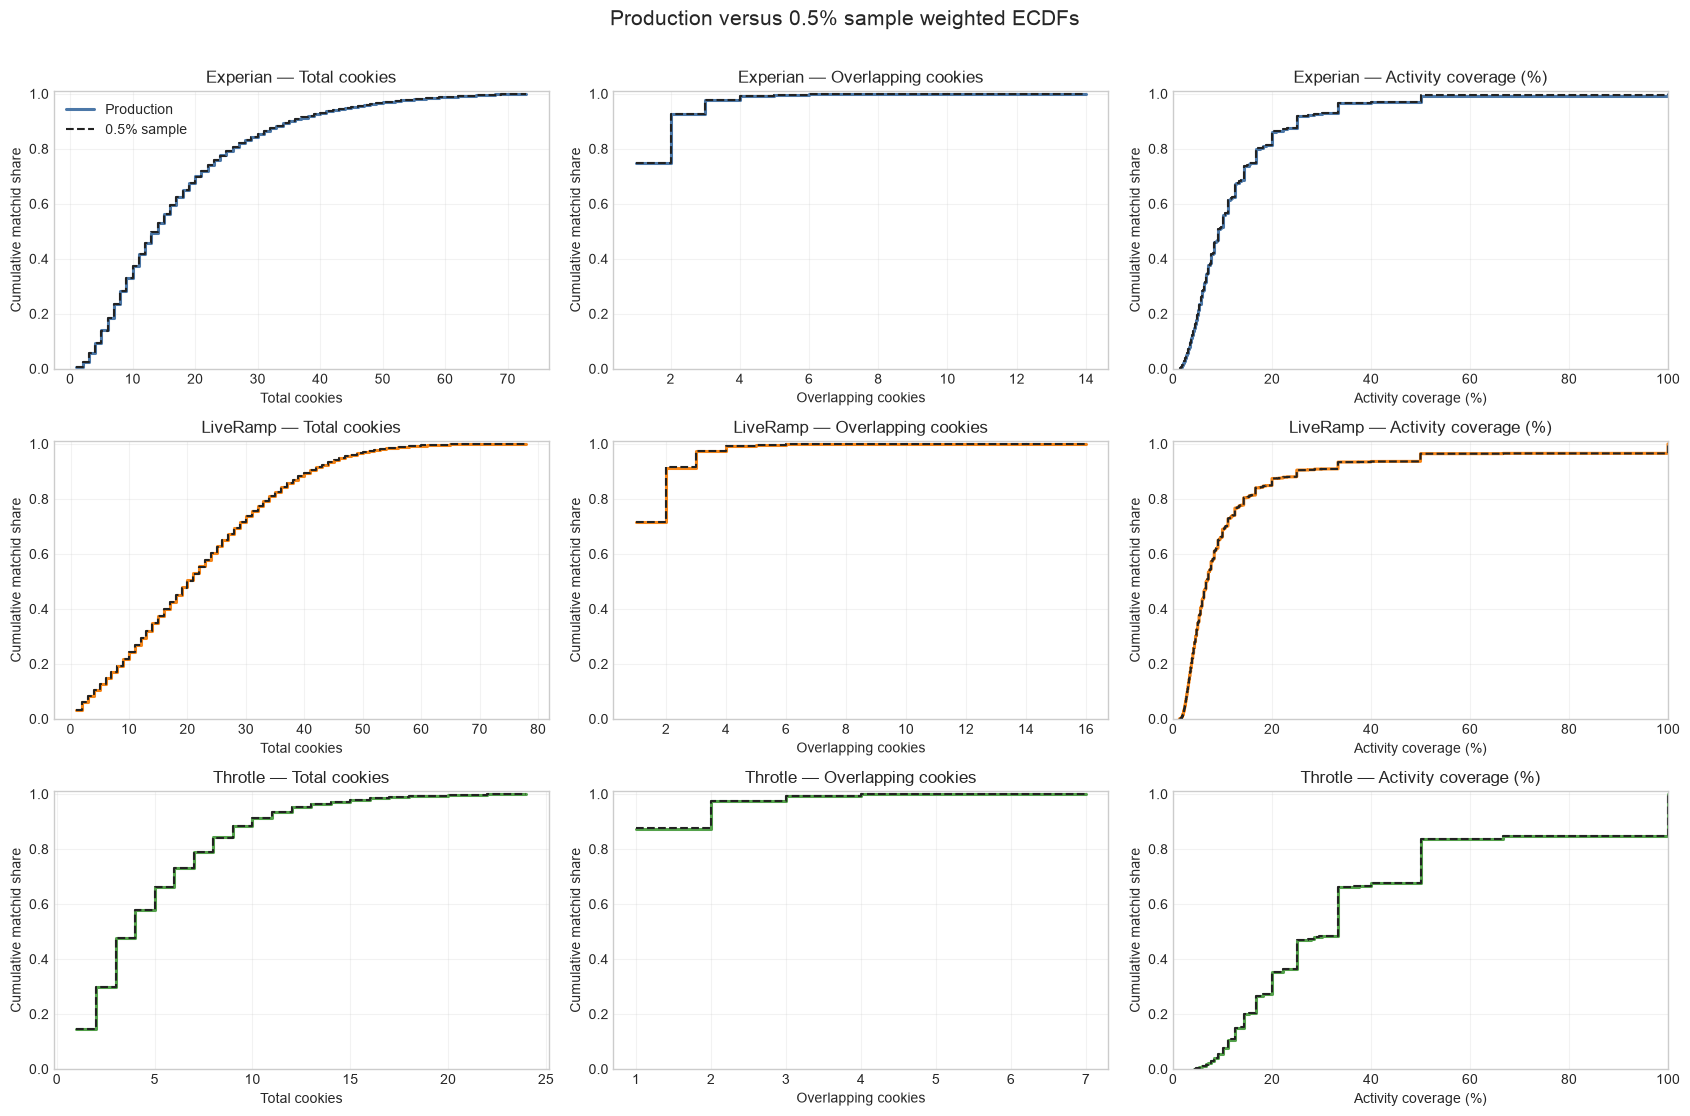

Saved: outputs/vendor_activity_coverage/figures/sample_vs_production_ecdf_2026-09-16_0p5pct.png


In [6]:
def weighted_ecdf(
    frame: pd.DataFrame,
    value_column: str,
    weight_column: str,
) -> tuple[np.ndarray, np.ndarray]:
    distribution = (
        frame.groupby(value_column, as_index=False)[weight_column]
        .sum()
        .sort_values(value_column)
    )
    cumulative_share = (
        distribution[weight_column].cumsum()
        / distribution[weight_column].sum()
    )
    return distribution[value_column].to_numpy(), cumulative_share.to_numpy()

vendors = sorted(stats.vendor.unique())
fig, axes = plt.subplots(len(vendors), len(METRICS), figsize=(17, 11))

for row_index, vendor in enumerate(vendors):
    vendor_stats = stats.loc[stats.vendor.eq(vendor)]
    for column_index, (metric, metric_label) in enumerate(METRICS.items()):
        axis = axes[row_index, column_index]
        production_x, production_y = weighted_ecdf(
            vendor_stats,
            metric,
            'production_matchid_count',
        )
        sample_x, sample_y = weighted_ecdf(
            vendor_stats,
            metric,
            'sample_matchid_count',
        )
        axis.step(
            production_x,
            production_y,
            where='post',
            color=VENDOR_COLORS[vendor],
            linewidth=2.2,
            label='Production',
        )
        axis.step(
            sample_x,
            sample_y,
            where='post',
            color='#222222',
            linewidth=1.5,
            linestyle='--',
            label='0.5% sample',
        )
        if metric == 'activity_coverage_pct':
            axis.set_xlim(0, 100)
        axis.set_ylim(0, 1.01)
        axis.set_xlabel(metric_label)
        axis.set_ylabel('Cumulative matchid share')
        axis.set_title(f'{VENDOR_LABELS[vendor]} — {metric_label}')
        axis.grid(True, alpha=0.25)
        if row_index == 0 and column_index == 0:
            axis.legend(frameon=False)

fig.suptitle('Production versus 0.5% sample weighted ECDFs', fontsize=15, y=1.01)
fig.tight_layout()
ecdf_path = FIGURE_DIR / f'sample_vs_production_ecdf_{CACHE_KEY}.png'
fig.savefig(ecdf_path, dpi=160, bbox_inches='tight')
plt.show()
print(f'Saved: {ecdf_path}')

## Cumulative distribution deltas

These plots expose differences hidden by nearly overlapping ECDF curves. Values show sample cumulative share minus production cumulative share, in percentage points.

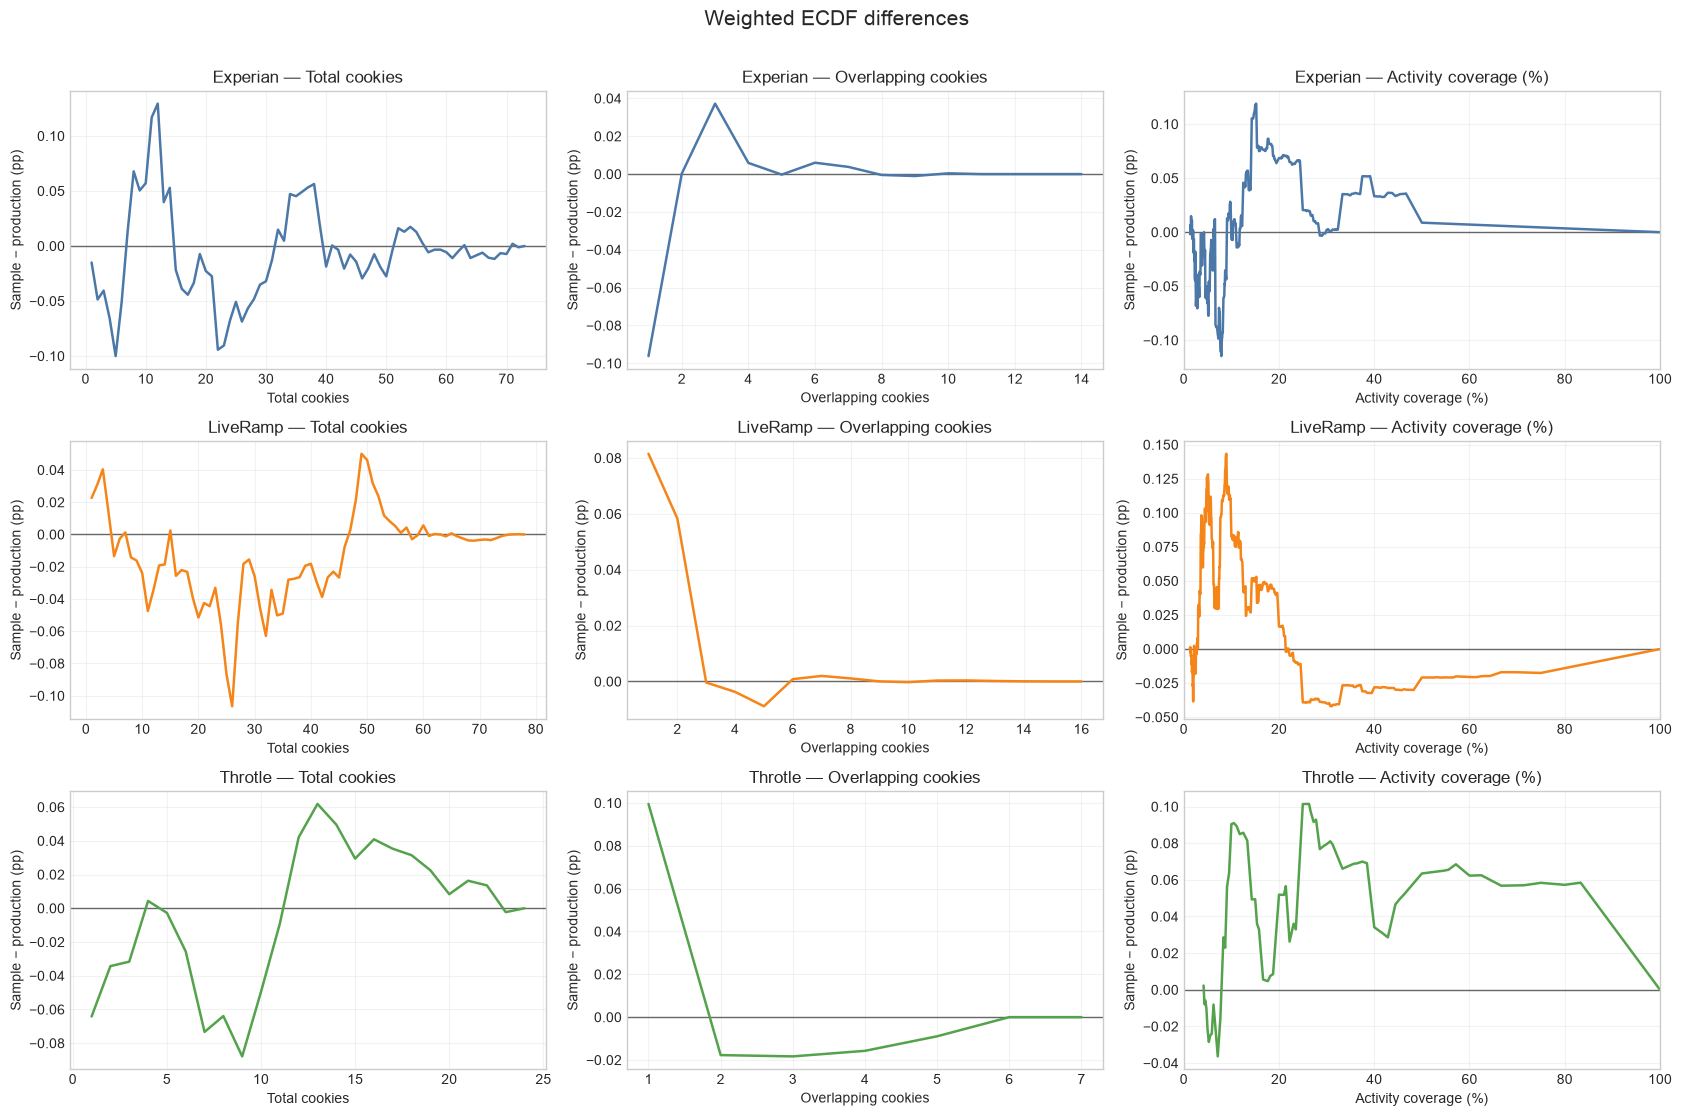

Saved: outputs/vendor_activity_coverage/figures/sample_vs_production_ecdf_delta_2026-09-16_0p5pct.png


In [7]:
fig, axes = plt.subplots(len(vendors), len(METRICS), figsize=(17, 11))

for row_index, vendor in enumerate(vendors):
    vendor_stats = stats.loc[stats.vendor.eq(vendor)]
    for column_index, (metric, metric_label) in enumerate(METRICS.items()):
        axis = axes[row_index, column_index]
        distribution = (
            vendor_stats.groupby(metric, as_index=False)[
                ['production_matchid_count', 'sample_matchid_count']
            ]
            .sum()
            .sort_values(metric)
        )
        production_cdf = (
            distribution.production_matchid_count.cumsum()
            / distribution.production_matchid_count.sum()
        )
        sample_cdf = (
            distribution.sample_matchid_count.cumsum()
            / distribution.sample_matchid_count.sum()
        )
        delta_pct_points = 100 * (sample_cdf - production_cdf)

        axis.axhline(0, color='#666666', linewidth=1)
        axis.plot(
            distribution[metric],
            delta_pct_points,
            color=VENDOR_COLORS[vendor],
            linewidth=1.8,
        )
        if metric == 'activity_coverage_pct':
            axis.set_xlim(0, 100)
        axis.set_xlabel(metric_label)
        axis.set_ylabel('Sample − production (pp)')
        axis.set_title(f'{VENDOR_LABELS[vendor]} — {metric_label}')
        axis.grid(True, alpha=0.25)

fig.suptitle('Weighted ECDF differences', fontsize=15, y=1.01)
fig.tight_layout()
delta_path = FIGURE_DIR / f'sample_vs_production_ecdf_delta_{CACHE_KEY}.png'
fig.savefig(delta_path, dpi=160, bbox_inches='tight')
plt.show()
print(f'Saved: {delta_path}')

## Pairwise count distribution

Each point represents one unique combination of total and overlapping cookie counts. Color and point size encode the within-cohort matchid share, allowing direct comparison despite the 200× population-size difference.

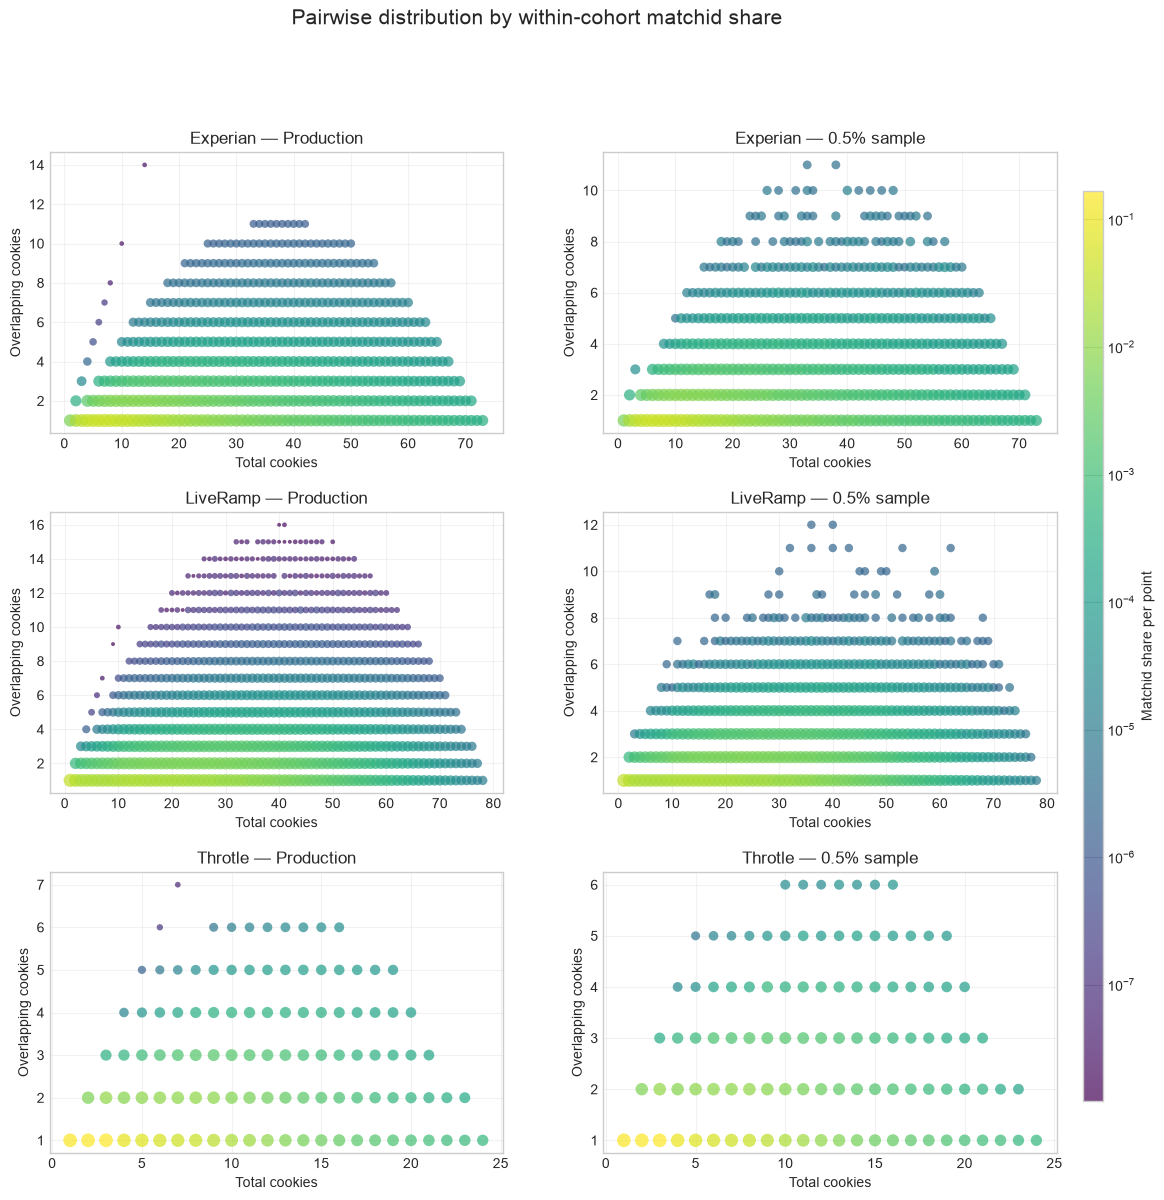

Saved: outputs/vendor_activity_coverage/figures/sample_vs_production_pairwise_2026-09-16_0p5pct.png


In [8]:
pairwise_frames = []
for vendor in vendors:
    vendor_stats = stats.loc[stats.vendor.eq(vendor)].copy()
    vendor_stats['production_share'] = (
        vendor_stats.production_matchid_count
        / vendor_stats.production_matchid_count.sum()
    )
    vendor_stats['sample_share'] = (
        vendor_stats.sample_matchid_count
        / vendor_stats.sample_matchid_count.sum()
    )
    pairwise_frames.append(vendor_stats)

pairwise_stats = pd.concat(pairwise_frames, ignore_index=True)
positive_shares = np.concatenate([
    pairwise_stats.loc[
        pairwise_stats.production_share.gt(0),
        'production_share',
    ].to_numpy(),
    pairwise_stats.loc[
        pairwise_stats.sample_share.gt(0),
        'sample_share',
    ].to_numpy(),
])
share_norm = LogNorm(vmin=positive_shares.min(), vmax=positive_shares.max())

def share_marker_sizes(shares: pd.Series) -> np.ndarray:
    lower = np.log10(positive_shares.min())
    upper = np.log10(positive_shares.max())
    scaled = (np.log10(shares.to_numpy()) - lower) / (upper - lower)
    return 8 + 90 * np.clip(scaled, 0, 1)

fig, axes = plt.subplots(len(vendors), 2, figsize=(13, 13), squeeze=False)
last_scatter = None
for row_index, vendor in enumerate(vendors):
    vendor_stats = pairwise_stats.loc[pairwise_stats.vendor.eq(vendor)]
    for column_index, (share_column, cohort_label) in enumerate([
        ('production_share', 'Production'),
        ('sample_share', '0.5% sample'),
    ]):
        axis = axes[row_index, column_index]
        plot_stats = vendor_stats.loc[vendor_stats[share_column].gt(0)]
        last_scatter = axis.scatter(
            plot_stats.total_cookie_count,
            plot_stats.overlapping_cookie_count,
            s=share_marker_sizes(plot_stats[share_column]),
            c=plot_stats[share_column],
            cmap='viridis',
            norm=share_norm,
            alpha=0.70,
            linewidths=0,
        )
        axis.set_xlabel('Total cookies')
        axis.set_ylabel('Overlapping cookies')
        axis.set_title(f'{VENDOR_LABELS[vendor]} — {cohort_label}')
        axis.grid(True, alpha=0.25)

fig.suptitle('Pairwise distribution by within-cohort matchid share', fontsize=15, y=0.99)
fig.subplots_adjust(right=0.90, hspace=0.28, wspace=0.22)
colorbar_axis = fig.add_axes([0.92, 0.15, 0.015, 0.70])
colorbar = fig.colorbar(last_scatter, cax=colorbar_axis)
colorbar.set_label('Matchid share per point')
pairwise_path = FIGURE_DIR / f'sample_vs_production_pairwise_{CACHE_KEY}.png'
fig.savefig(pairwise_path, dpi=160, bbox_inches='tight')
plt.show()
print(f'Saved: {pairwise_path}')

## Interpretation and limitations

- Passing diagnostics means the 0.5% cohort reproduces retained production distributions for the three measured activity features on `2026-09-16`.
- The comparison does not validate upstream eligibility logic because it starts from persisted eligibility tables.
- Matching marginal and pairwise count distributions does not prove that cross-vendor graph connectivity is representative. Vendors were sampled independently, so shared-cookie bridges may be omitted.
- Results cover one source day. Temporal representativeness requires repeating the comparison across additional dates.
- Hash sampling is deterministic. The diagnostic thresholds describe practical similarity and should not be interpreted as random-sample confidence tests.